# Brain Tumor MRI Classification Demo

This notebook demonstrates an end-to-end workflow for **brain tumor MRI classification** using **PyTorch** and a **pretrained ResNet backbone**.

## Task
Classify brain MRI images into 4 categories:
- glioma
- meningioma
- notumor
- pituitary

## Project structure
- `src/data.py`: dataset and dataloader utilities
- `src/model.py`: model construction and fine-tuning utilities
- `src/train_eval.py`: training, validation, testing, and plotting
- `src/inference.py`: single-image inference

## Demo mode
This notebook follows **Scheme B**:
- it **does not train by default**
- it **loads an existing checkpoint**
- it **evaluates on the test set**
- it optionally supports **single-image inference**

Core logic is intentionally modularized in `src/` for readability and maintainability.

In [1]:
from pathlib import Path
import sys

# Notebook path: notebooks/demo.ipynb
# Project root is assumed to be the parent folder of "notebooks/".
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: F:\brain-tumor-mri-classification


In [2]:
from src.data import create_dataloaders
from src.model import build_model
from src.train_eval import (
    set_seed,
    get_device,
    fit_model,
    plot_history,
    load_checkpoint,
    test_and_report,
    save_final_model,
)
from src.inference import predict_one_image

import matplotlib.pyplot as plt
import torch

In [3]:
SEED = 1
IMG_SIZE = 256
BATCH_SIZE = 32
VAL_SPLIT = 0.2

EPOCHS_STAGE1 = 30
EPOCHS_STAGE2 = 15
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-4
WEIGHT_DECAY = 1e-4

HEAD_TYPE = "linear"           # "linear" or "deep_mlp"
CLASS_WEIGHTS = [1.5, 1, 1, 1]   # Example: [3, 1.2, 1, 1]
RUN_TRAINING = True           # True to train from scratch, False to load an existing checkpoint
SAVE_FINAL_MODEL = False


In [4]:
def _format_weight_value(x):
    """
    Format weight values for method names.
    Examples:
        3.0 -> "3"
        1.2 -> "1.2"
    """
    x = float(x)
    if x.is_integer():
        return str(int(x))
    return str(x)


def build_method_config(head_type: str, class_weights=None):
    """
    Build method config from:
    - head_type
    - class_weights

    Rules:
    - If all weights are 1, treat as the plain baseline method.
    - Otherwise generate a weighted-CE method name automatically.
    - Only non-1 weights will appear in the method name.
    """
    if head_type not in ["linear", "deep_mlp"]:
        raise ValueError(f"Unsupported HEAD_TYPE: {head_type}")

    class_abbrs = ["gli", "men", "nt", "pit"]

    if class_weights is None:
        return {
            "method_name": head_type,
            "head_type": head_type,
            "class_weights": None,
        }

    if len(class_weights) != 4:
        raise ValueError("CLASS_WEIGHTS must have length 4.")

    class_weights = [float(w) for w in class_weights]

    if all(abs(w - 1.0) < 1e-8 for w in class_weights):
        return {
            "method_name": head_type,
            "head_type": head_type,
            "class_weights": None,
        }

    changed_parts = []
    for abbr, w in zip(class_abbrs, class_weights):
        if abs(w - 1.0) >= 1e-8:
            changed_parts.append(f"{abbr}_{_format_weight_value(w)}")

    suffix = "_".join(changed_parts)
    method_name = f"{head_type}_weighted_ce_{suffix}"

    return {
        "method_name": method_name,
        "head_type": head_type,
        "class_weights": class_weights,
    }


method_cfg = build_method_config(
    head_type=HEAD_TYPE,
    class_weights=CLASS_WEIGHTS,
)

METHOD_NAME = method_cfg["method_name"]
HEAD_TYPE = method_cfg["head_type"]
CLASS_WEIGHTS = method_cfg["class_weights"]

DATA_ROOT = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models" / METHOD_NAME / f"seed_{SEED}"
CHECKPOINT_PATH = MODELS_DIR / "best_pytorch.pt"

set_seed(SEED)
device = get_device()

print("Using device:", device)
print("Data root:", DATA_ROOT)
print("METHOD_NAME:", METHOD_NAME)
print("HEAD_TYPE:", HEAD_TYPE)
print("CLASS_WEIGHTS:", CLASS_WEIGHTS)
print("Models dir:", MODELS_DIR)
print("Checkpoint path:", CHECKPOINT_PATH)

Using device: cuda
Data root: F:\brain-tumor-mri-classification\data
METHOD_NAME: linear_weighted_ce_gli_1.5
HEAD_TYPE: linear
CLASS_WEIGHTS: [1.5, 1.0, 1.0, 1.0]
Models dir: F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.5\seed_1
Checkpoint path: F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.5\seed_1\best_pytorch.pt


## Load dataset

The dataset is expected in one of the following formats:

- `data/Training/<class_name>/*.jpg`
- `data/Testing/<class_name>/*.jpg`

or

- `Training/<class_name>/*.jpg`
- `Testing/<class_name>/*.jpg`

In [5]:
data_dict = create_dataloaders(
    data_root=str(DATA_ROOT),
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=SEED,
    device=device,
)

train_loader = data_dict["train_loader"]
val_loader = data_dict["val_loader"]
test_loader = data_dict["test_loader"]
class_names = data_dict["class_names"]
eval_tfms = data_dict["eval_tfms"]

print("Classes:", class_names)
print("Train size:", data_dict["train_size"])
print("Val size:", data_dict["val_size"])
print("Test size:", data_dict["test_size"])

Dataset found: F:\brain-tumor-mri-classification\data
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 4480
Val size: 1120
Test size: 1600


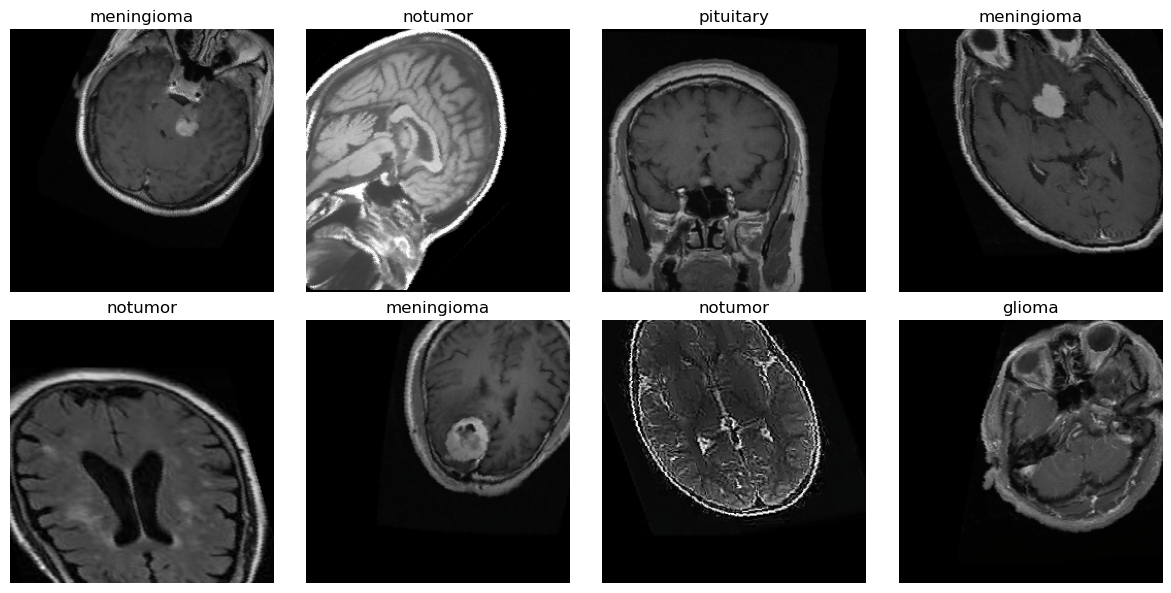

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(min(8, len(images))):
    img = images[i].permute(1, 2, 0).cpu().numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)

    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Build model

We use a pretrained ResNet backbone for transfer learning.

- Preferred: `timm` ResNetV2-50
- Fallback: `torchvision` ResNet-50

In [7]:
model, backbone_name = build_model(
    num_classes=len(class_names),
    head_type=HEAD_TYPE,
)
model = model.to(device)

print("Backbone:", backbone_name)

Backbone: torchvision:resnet50 + linear


## Load or train

This demo notebook skips training by default.  
If `RUN_TRAINING = False`, it will load `models/best_pytorch.pt`.

Set `RUN_TRAINING = True` only if you want to train from scratch in this notebook.

In [8]:
if RUN_TRAINING:
    history, best_path = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs_stage1=EPOCHS_STAGE1,
        epochs_stage2=EPOCHS_STAGE2,
        lr_stage1=LR_STAGE1,
        lr_stage2=LR_STAGE2,
        weight_decay=WEIGHT_DECAY,
        fine_tune=True,
        unfreeze_last_n=30,
        models_dir=str(MODELS_DIR),
        class_weights=CLASS_WEIGHTS,
    )
    print("Best checkpoint:", best_path)
else:
    best_path = CHECKPOINT_PATH
    if not best_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {best_path}\n"
            "Set RUN_TRAINING = True to train a model, or place the checkpoint at the path above."
        )
    print("Skip training. Use existing checkpoint:", best_path)

Using class weights: [1.5, 1.0, 1.0, 1.0]


F:\brain-tumor-mri-classification\src\train_eval.py:128: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
F:\brain-tumor-mri-classification\src\train_eval.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[Stage-1][01/30] train_loss=0.8606 train_acc=0.6993 | val_loss=0.8626 val_acc=0.7214
[Stage-1][02/30] train_loss=0.5771 train_acc=0.8038 | val_loss=0.7141 val_acc=0.7857
[Stage-1][03/30] train_loss=0.4906 train_acc=0.8275 | val_loss=0.6683 val_acc=0.8134
[Stage-1][04/30] train_loss=0.4532 train_acc=0.8373 | val_loss=0.5731 val_acc=0.8366
[Stage-1][05/30] train_loss=0.4399 train_acc=0.8373 | val_loss=0.5450 val_acc=0.8402
[Stage-1][06/30] train_loss=0.4185 train_acc=0.8529 | val_loss=0.5413 val_acc=0.8429
[Stage-1][07/30] train_loss=0.3964 train_acc=0.8562 | val_loss=0.5073 val_acc=0.8545
[Stage-1][08/30] train_loss=0.3827 train_acc=0.8641 | val_loss=0.5317 val_acc=0.8277
[Stage-1][09/30] train_loss=0.3727 train_acc=0.8616 | val_loss=0.4858 val_acc=0.8625
[Stage-1][10/30] train_loss=0.3739 train_acc=0.8696 | val_loss=0.4734 val_acc=0.8545
[Stage-1][11/30] train_loss=0.3605 train_acc=0.8618 | val_loss=0.4754 val_acc=0.8536
[Stage-1][12/30] train_loss=0.3479 train_acc=0.8670 | val_loss=0.

Accuracy curve saved to: outputs\linear_weighted_ce_gli_1.5\seed_1\accuracy_curve.png


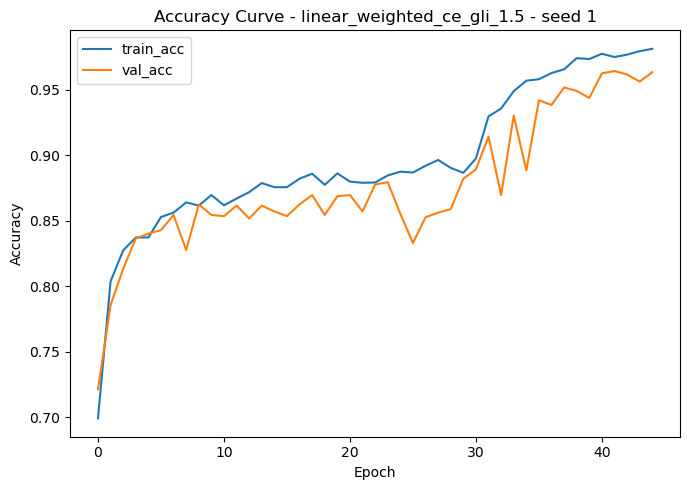

Loss curve saved to: outputs\linear_weighted_ce_gli_1.5\seed_1\loss_curve.png


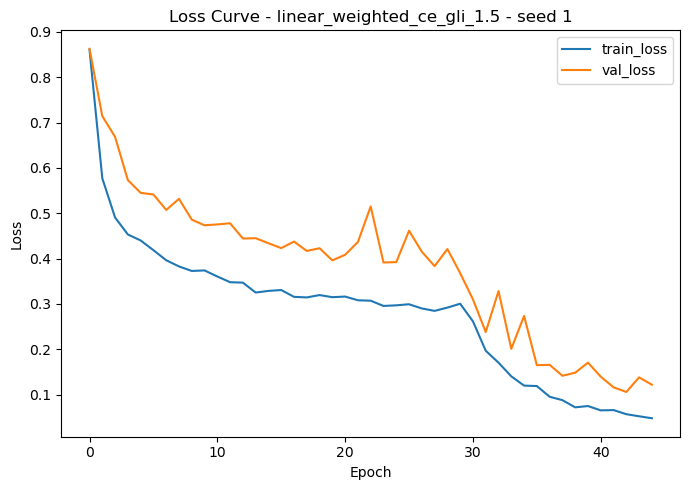

In [9]:
if "history" in locals():
    plot_history(
        history,
        method_name=METHOD_NAME,
        seed=SEED,
        save_plots=True,
        show_plots=True,
    )
else:
    print("Training curves are only available when RUN_TRAINING = True.")

In [10]:
model = load_checkpoint(model, best_path, device)
print("Checkpoint loaded.")

Checkpoint loaded.


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

## Test set evaluation

We report:
- overall accuracy
- per-class precision / recall / F1-score
- confusion matrix

Test accuracy: 0.92875
Classification report:
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.94      0.98      0.96       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600

Confusion matrix saved to: outputs\linear_weighted_ce_gli_1.5\seed_1\confusion_matrix_test.png


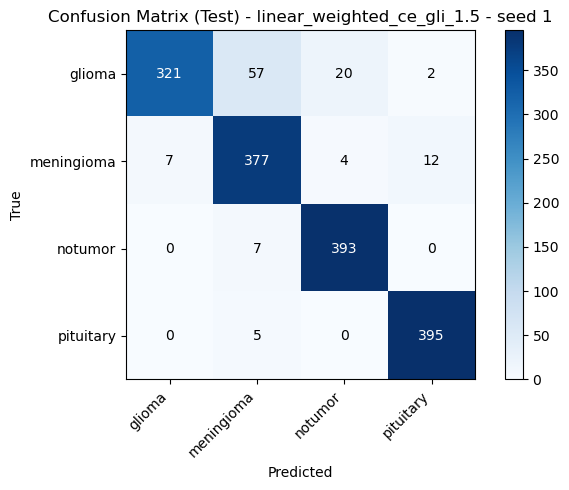

Test accuracy: 0.92875


In [11]:
results = test_and_report(
    model=model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    show_confusion_matrix=True,
    method_name=METHOD_NAME,
    seed=SEED,
    save_confusion_matrix=True,
)

print("Test accuracy:", results["accuracy"])

In [12]:
if SAVE_FINAL_MODEL:
    save_final_model(model, str(MODELS_DIR / "final_pytorch.pt"))
else:
    print("Skip saving final model. Set SAVE_FINAL_MODEL = True if needed.")

Skip saving final model. Set SAVE_FINAL_MODEL = True if needed.


## Single-image inference

Set `SAMPLE_IMAGE` to a valid image path if you want to run prediction on one image.

In [13]:
SAMPLE_IMAGE = None  # Example: PROJECT_ROOT / "data" / "Testing" / "glioma" / "some_image.jpg"

if SAMPLE_IMAGE is not None:
    label, conf, probs = predict_one_image(
        model=model,
        img_path=str(SAMPLE_IMAGE),
        eval_tfms=eval_tfms,
        class_names=class_names,
        device=device,
    )
    print("Predicted label:", label)
    print("Confidence:", conf)
    print("Probabilities:", probs)
else:
    print("Set SAMPLE_IMAGE to run single-image inference.")

Set SAMPLE_IMAGE to run single-image inference.


## Summary

This notebook demonstrates the complete workflow for brain tumor MRI classification:
- data loading
- transfer learning with a pretrained ResNet backbone
- loading an existing checkpoint
- test evaluation
- single-image inference

All core implementation lives in `src/`, while this notebook focuses on clear presentation and reproducible usage.